# Pipeline: Từ dữ liệu đến tệp nộp bài

Notebook này gom các bước từ nạp dữ liệu đến tạo tệp nộp bài trong một phiên Google Colab:
1. Thiết lập môi trường và cấu hình hai nhánh RGB Native 358 và High-pass.
2. Nạp dữ liệu, kiểm tra và chia tập train/validation.
3. Huấn luyện hai mô hình ResNet34 hoặc nạp checkpoint đã lưu.
4. Lấy trung bình xác suất của hai nhánh theo tỷ lệ 50/50.
5. Dự đoán trên 200 ảnh Private Test, tạo và kiểm tra `submission.zip`.

In [ ]:
from pathlib import Path
import importlib
import os
import subprocess
import sys

URL = "https://github.com/Purin1410/Olympic_AI_PTIT_2026_preliminary_round.git"
REF = os.environ.get("AILAAI_RELEASE_REF", "main")
# Reuse a local checkout when the notebook is opened from this repository.
TASK = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/ailaai").is_dir() and (p / "pyproject.toml").is_file()), None)
if TASK is None:
    REPO = Path("/content" if Path("/content").is_dir() else Path.cwd()) / "Olympic_AI_PTIT_2026_preliminary_round"
    if not REPO.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", REF, URL, str(REPO)], check=True)
    TASK = REPO / "AI_LA_AI"
else:
    REPO = TASK.parent
if not (TASK / "src/ailaai").is_dir():
    raise FileNotFoundError(f"Không tìm thấy package AI Là AI trong {TASK}.")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(TASK / "requirements-colab.txt"), "-e", str(TASK)], check=True)
src_path = str((TASK / "src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)
importlib.invalidate_caches()
import ailaai
if Path(ailaai.__file__).resolve().parent != TASK.resolve() / "src/ailaai":
    raise RuntimeError("Phiên đang dùng bản ailaai ở thư mục khác. Khởi động lại phiên rồi chạy từ đầu.")
print("Đã sẵn sàng:", TASK)

Đã sẵn sàng: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI


In [ ]:
from ailaai.config import Workspace
from ailaai.resources import check_environment, verify_checkout
RUN_ID = "student_e2e_reading_v2"
ws = Workspace.from_root(TASK, run_id=RUN_ID)
verify_checkout(REPO)
check_environment(profile="e2e")
print(ws.summary())

{'root': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI', 'data_root': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/data', 'reference_root': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/reference_artifacts', 'artifact_root': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/student_e2e_reading_v2', 'output_root': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2'}


In [ ]:
from pathlib import Path
from typing import Any, Callable, Mapping, Iterable
from dataclasses import dataclass, replace
import hashlib, json, time, os, tempfile, zipfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.prop_cycle": plt.cycler(color=["#2563A6", "#C17817", "#7A5BA7"])})
from IPython.display import display
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import functional as TF, InterpolationMode
from ailaai.config import TrainConfig, Workspace, write_json
from ailaai.data import decode_rgb
from ailaai.models import attach_optimizer_groups
from ailaai.metrics import classification_report
from ailaai.predictions import PredictionTable
from ailaai.resources import sha256_file
# Các hàm dưới quản lý checkpoint/config; phép học được viết ở các cell tiếp theo.
from ailaai.engine import (RunInfo, _resolved_config, _run_directory, _load_checkpoint,
                          _seed, _save_curves, _checkpoint_state, _callable_digest)
ModelFactory = Callable[..., nn.Module]
ViewFunction = Callable[[torch.Tensor], torch.Tensor]

## 1. Cấu hình huấn luyện và mô hình

Ở cell dưới, bạn có thể chọn chế độ cho từng nhánh trong `MODE`: `"train"` để huấn luyện hoặc `"load"` để nạp checkpoint đã lưu.

Các tham số `epochs`, `backbone_lr` và `head_lr` lần lượt quy định số epoch và tốc độ học (learning rate) của phần thân mạng (backbone) và tầng phân loại (head). Cấu hình mặc định dùng ResNet34 với trọng số ImageNet và vùng cắt trung tâm $358 \times 358$, giữ nguyên pixel gốc.

In [ ]:
from dataclasses import replace
from ailaai.config import load_config, read_json
e2e_cfg = read_json(TASK / "configs/e2e.json")
MODE = e2e_cfg["default_modes"].copy()
MODEL_SPEC = {"backbone": "resnet34", "weights": "IMAGENET1K_V1"}
rgb_cfg = replace(load_config(TASK / "configs/rgb_native358.json"),
                  epochs=15, backbone_lr=1.5e-4, head_lr=7.5e-4,
                  model=MODEL_SPEC.copy())
hp_cfg = replace(load_config(TASK / "configs/highpass358.json"),
                 epochs=15, backbone_lr=1.5e-4, head_lr=7.5e-4,
                 model=MODEL_SPEC.copy())
assert set(MODE.values()) <= {"train", "load"}
check_environment(profile="train" if "train" in MODE.values() else "infer")
print(rgb_cfg)
print(hp_cfg)

TrainConfig(seed=2026, epochs=15, batch_size=16, accumulation=2, backbone_lr=0.00015, head_lr=0.00075, weight_decay=0.0001, label_smoothing=0.0, optimizer='adamw', scheduler='cosine', checkpoint_policy='terminal', model=mappingproxy({'backbone': 'resnet34', 'weights': 'IMAGENET1K_V1'}), view=mappingproxy({'name': 'native', 'crop': 358}), normalize_mean=(0.485, 0.456, 0.406), normalize_std=(0.229, 0.224, 0.225), augmentation=mappingproxy({'horizontal_flip_probability': 0.5}), tta=False)
TrainConfig(seed=2026, epochs=15, batch_size=16, accumulation=2, backbone_lr=0.00015, head_lr=0.00075, weight_decay=0.0001, label_smoothing=0.0, optimizer='adamw', scheduler='cosine', checkpoint_policy='terminal', model=mappingproxy({'backbone': 'resnet34', 'weights': 'IMAGENET1K_V1'}), view=mappingproxy({'name': 'highpass', 'crop': 358, 'kernel': 5, 'sigma': 1.0, 'gain': 2.0, 'offset': 0.5}), normalize_mean=(0.485, 0.456, 0.406), normalize_std=(0.229, 0.224, 0.225), augmentation=mappingproxy({'horizonta

## 2. Nạp và kiểm tra dữ liệu

Bộ dữ liệu có tại [who_is_AI (Google Drive)](https://drive.google.com/file/d/1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq/view?usp=drive_link). Phần nạp dữ liệu sử dụng thư mục `data/` và cấu hình nguồn tải của bài.

Tập train có 2.000 ảnh với nhãn $0 = \text{Real}$ và $1 = \text{Fake}$. Tập Private Test có 200 ảnh không kèm nhãn.

Trước khi huấn luyện, kiểm tra số ảnh, phân bố nhãn và mở thử vài ảnh để xem dữ liệu đã được đọc đúng chưa.

Đang tải bộ dữ liệu từ Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq
From (redirected): https://drive.google.com/uc?id=1g_43_Xn-DWYB-k7Yq4XQTr5ZQXZ0UdXq&confirm=t&uuid=4f551bba-0eff-4f58-aeb4-64ecd4babaf4
To: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/data/who_is_AI.zip.partial
100%|██████████| 146M/146M [00:02<00:00, 58.8MB/s]


Đang giải nén và kiểm tra dữ liệu...
Dữ liệu đã sẵn sàng: train 2000 ảnh, test 200 ảnh
Train: 2000 Test: 200


,count
label,
Real,1000
Fake,1000


,file_name
0,00001.jpg
1,00002.jpg
2,00003.jpg
3,00004.jpg
4,00005.jpg


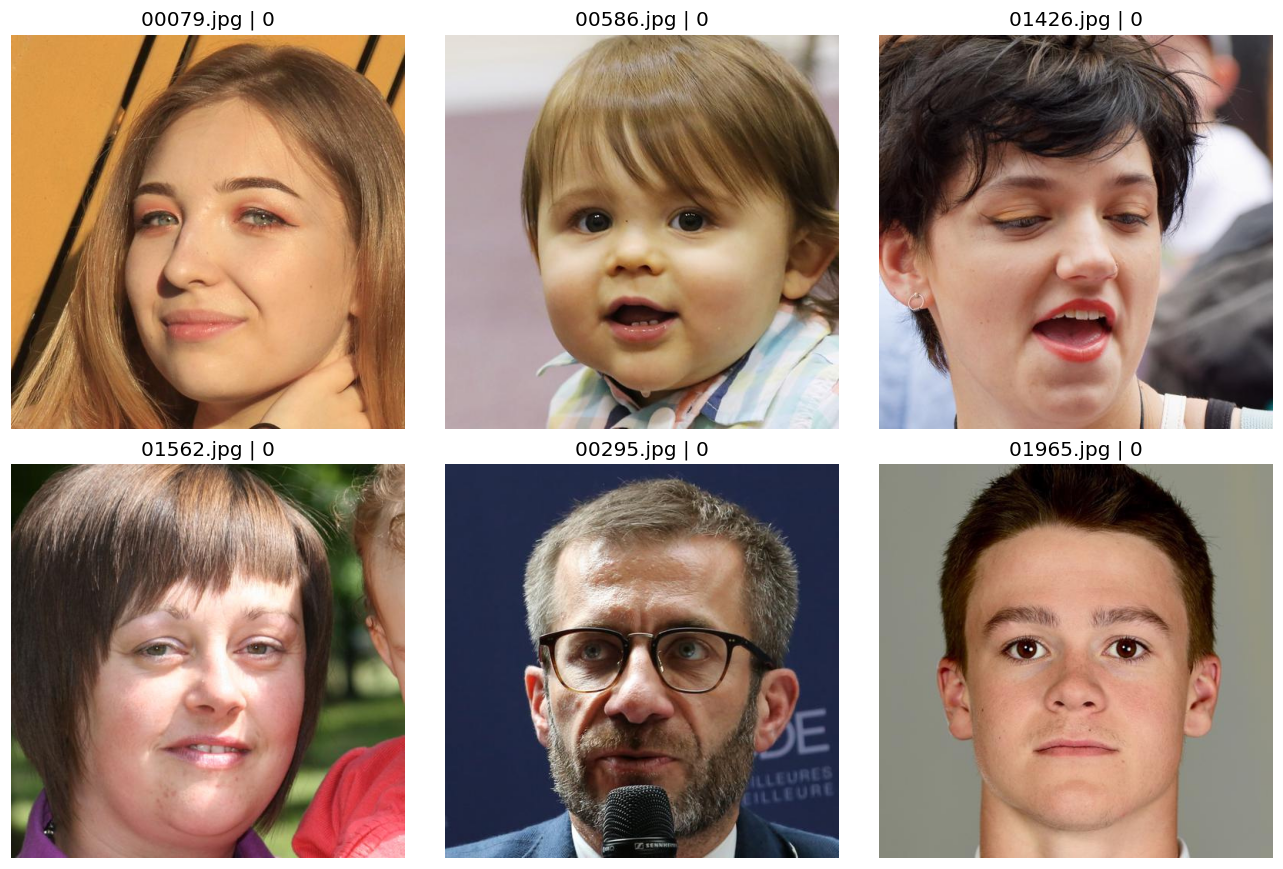

In [ ]:
from ailaai.resources import prepare_resources
from ailaai.data import load_train_manifest, load_test_manifest, validate_data
from ailaai.visuals import show_samples

resources = TASK / "configs/resources.json"
prepare_resources(ws, resources, profile="e2e")
train = load_train_manifest(ws)
test = load_test_manifest(ws)
validate_data(train, test, resource_manifest=resources)
print("Train:", len(train), "Test:", len(test))
display(train.label.value_counts().rename(index={0: "Real", 1: "Fake"}))
display(test[["file_name"]].head())
_ = show_samples(train, label_col="label", n=6)

## 3. Chia tập train và validation

Hai nhánh RGB và High-pass dùng cùng bảng chia fold ở `assets/splits/train_folds.csv` để được đánh giá trên cùng các ảnh validation.

Ảnh validation không được dùng để cập nhật trọng số. Ta dùng kết quả trên tập này để theo dõi quá trình học và so sánh các phương án.

In [ ]:
from ailaai.data import load_fold_split
fit_rows, val_rows = load_fold_split(
    train, TASK / e2e_cfg["split_path"], fold=e2e_cfg["fold"])
assert set(fit_rows.file_name).isdisjoint(val_rows.file_name)
assert len(fit_rows) + len(val_rows) == len(train)
print("Train:", len(fit_rows), "Validation:", len(val_rows))
display(val_rows.label.value_counts().sort_index())

Train: 1600 Validation: 400


,count
label,
0,200
1,200


## Khám phá dữ liệu trước khi huấn luyện

Trước hết, ta xem toàn bộ tập train: mỗi lớp có bao nhiêu ảnh, ảnh có cùng kích thước không, dung lượng JPEG phân bố ra sao và có ảnh nào trùng nội dung. Hai phỏng đoán trong Reading II.2 cũng được kiểm tra ở đây: ảnh nhỏ hơn có dễ là Fake hơn không, và ảnh xám có phải đều là Real?

Cột `is_gray` yêu cầu R=G=B trên mọi pixel. Cột `near_gray` cho phép chênh lệch nhỏ giữa các kênh, để ta thấy kết quả có phụ thuộc cách định nghĩa ảnh xám hay không.

In [ ]:
# Định nghĩa trực tiếp trong cell: image_census
def image_census(rows):
    """Read every image; record size, exact gray flag and duplicate content."""
    records = []
    for row in rows.itertuples():
        path = Path(row.path)
        with Image.open(path) as image:
            original_mode = image.mode
            rgb = np.asarray(image.convert("RGB"))
        delta = rgb.max(axis=2).astype(float) - rgb.min(axis=2).astype(float)
        records.append({"file_name": row.file_name, "label": int(row.label),
                        "path": str(path), "width": rgb.shape[1], "height": rgb.shape[0],
                        "mode": original_mode, "size_kib": path.stat().st_size / 1024,
                        "is_gray": bool((delta == 0).all()),
                        "near_gray": bool(delta.mean() <= 1),
                        "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
    census = pd.DataFrame(records)
    if census.empty or not census.file_name.is_unique:
        raise ValueError("Image census requires nonempty rows with unique file names.")
    return census

In [ ]:
census = image_census(train)
display(census.groupby("label").agg(n=("file_name", "size"), gray=("is_gray", "sum"), near_gray=("near_gray", "sum")))
display(census.groupby(["width", "height", "mode"]).size().rename("Số ảnh").reset_index())
duplicates = census[census.duplicated("sha256", keep=False)]
print("Ảnh thuộc nhóm trùng byte:", len(duplicates))
if not duplicates.empty:
    display(duplicates[["file_name", "label", "sha256"]].head(20))
census.to_csv(ws.output_root / "eda_image_census.csv", index=False)

,n,gray,near_gray
label,,,
0,1000,500,500
1,1000,500,500


,width,height,mode,Số ảnh
0,512,512,RGB,2000


Ảnh thuộc nhóm trùng byte: 0


### Xem ảnh của từng nhóm

Mỗi hàng dưới đây ứng với một tổ hợp nhãn và cờ xám/màu. Seed cố định giúp các lần mở notebook chọn lại cùng ảnh. Hãy nhìn vùng mặt, nền và mức độ chi tiết; tên tệp dưới mỗi ảnh giúp ta quay lại kiểm tra khi cần. Nhận xét về vị trí khuôn mặt mới chỉ áp dụng cho những mẫu đang xem.

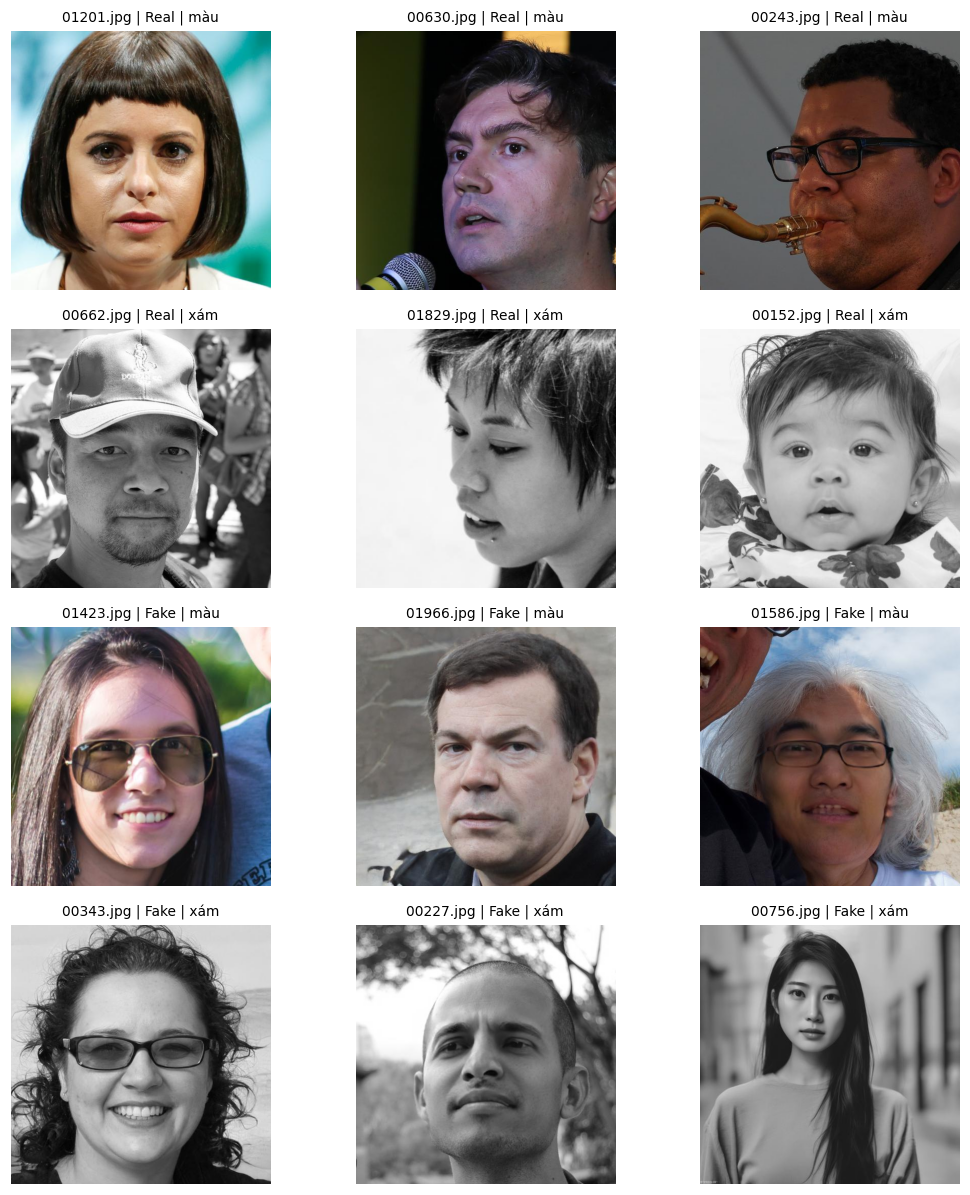

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(10, 11))
for row_index, (label, gray) in enumerate([(0, False), (0, True), (1, False), (1, True)]):
    group = census[(census.label == label) & (census.is_gray == gray)]
    selected = group.sample(min(3, len(group)), random_state=2026)
    for ax in axes[row_index]: ax.axis("off")
    for ax, row in zip(axes[row_index], selected.itertuples()):
        with Image.open(row.path) as im: ax.imshow(im.convert("RGB"))
        ax.set_title(f'{row.file_name} | {"Fake" if label else "Real"} | {"xám" if gray else "màu"}', fontsize=9)
fig.tight_layout(); plt.show()

### Dung lượng JPEG có tách được Real và Fake?

Nếu hai lớp khác nhau về dung lượng, một ngưỡng đơn giản có thể là điểm bắt đầu. Bảng dưới dùng KiB, tức số byte chia cho 1024; histogram cho thấy hai phân bố chồng lấn đến đâu.

Ta chọn ngưỡng theo Accuracy rồi so hai cách đánh giá: chọn và chấm ngay trên cả tập, hoặc chọn trên phần train của fold 0 rồi chấm trên validation. ROC-AUC dùng `-size_kib`, tương ứng với phỏng đoán ảnh Fake nhỏ hơn. Accuracy ở đây cần được phân biệt với Macro-F1 dùng để chấm bài thi.

In [ ]:
# Định nghĩa trực tiếp trong cell: choose_size_rule
def choose_size_rule(rows):
    """Select a JPEG-size threshold and direction on the supplied training rows."""
    values = np.sort(rows.size_kib.unique())
    candidates = np.r_[values[0] - 1, (values[:-1] + values[1:]) / 2, values[-1] + 1]
    best = None
    for fake_is_small in (True, False):
        for threshold in candidates:
            prediction = (rows.size_kib < threshold) if fake_is_small else (rows.size_kib >= threshold)
            accuracy = float((prediction.astype(int) == rows.label).mean())
            if best is None or accuracy > best["accuracy"]:
                best = {"threshold_kib": float(threshold), "fake_is_small": fake_is_small,
                        "accuracy": accuracy}
    return best

,mean,median,std,min,max
label,,,,,
Real,67.461741,66.120605,14.02457,36.719727,118.615234
Fake,57.325717,56.338379,13.91343,27.998047,111.082031


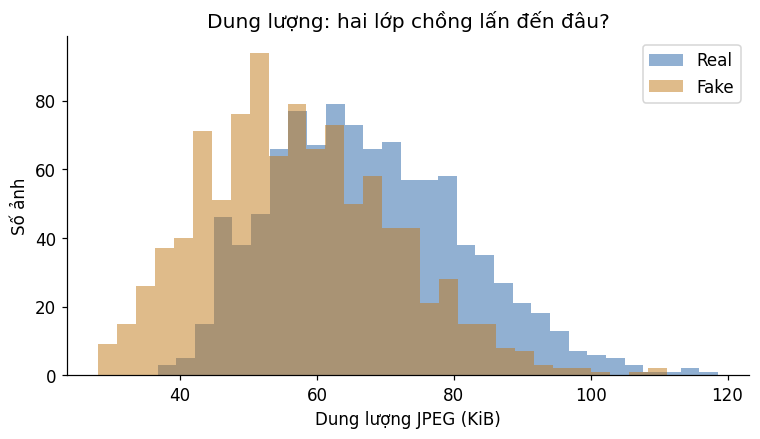

Chọn + chấm cả tập (mô tả): {'threshold_kib': 62.865234375, 'fake_is_small': True, 'accuracy': 0.639}
Chọn train fold 0: {'threshold_kib': 53.66015625, 'fake_is_small': True, 'accuracy': 0.639375} | Accuracy validation: 0.63
ROC-AUC mô tả, score=-size: 0.6953564999999999


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
size_summary = census.groupby("label").size_kib.agg(["mean", "median", "std", "min", "max"])
display(size_summary.rename(index={0: "Real", 1: "Fake"}))
fig, ax = plt.subplots(figsize=(8, 4))
for label, name in [(0, "Real"), (1, "Fake")]:
    ax.hist(census.loc[census.label == label, "size_kib"], bins=30, alpha=.5, label=name)
ax.set(xlabel="Dung lượng JPEG (KiB)", ylabel="Số ảnh", title="Dung lượng: hai lớp chồng lấn đến đâu?")
ax.legend(); plt.show()
all_rule = choose_size_rule(census)
fit_census = census[census.file_name.isin(fit_rows.file_name)]
val_census = census[census.file_name.isin(val_rows.file_name)]
fit_rule = choose_size_rule(fit_census)
val_pred = (val_census.size_kib < fit_rule["threshold_kib"]) if fit_rule["fake_is_small"] else (val_census.size_kib >= fit_rule["threshold_kib"])
print("Chọn + chấm cả tập (mô tả):", all_rule)
print("Chọn train fold 0:", fit_rule, "| Accuracy validation:", accuracy_score(val_census.label, val_pred))
print("ROC-AUC mô tả, score=-size:", roc_auc_score(census.label, -census.size_kib))

### Ảnh xám có phải đều là Real?

Bảng chéo đếm trực tiếp ảnh xám và ảnh màu trong mỗi lớp. Sau đó ta thử quy tắc “xám là Real, màu là Fake” và tính cả Accuracy lẫn Macro-F1.

Nếu hai lớp có cùng tỷ lệ ảnh xám, riêng cờ này sẽ không giúp tách lớp. Các thông tin màu khác vẫn có thể hữu ích.

,Màu,Xám
Real,500,500
Fake,500,500


Quy tắc xám→Real, màu→Fake: {'Accuracy': 0.5, 'Macro-F1': 0.5}


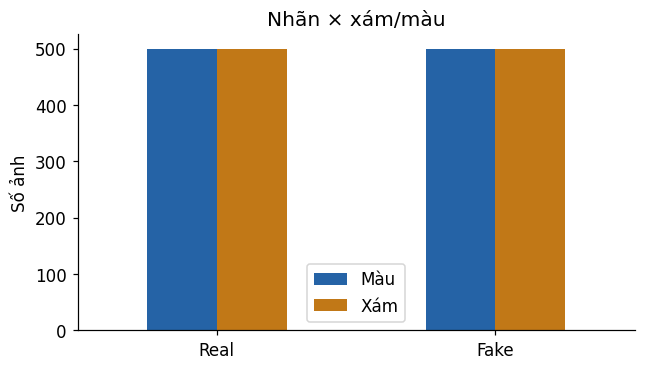

In [ ]:
from sklearn.metrics import f1_score
color_table = pd.crosstab(census.label, census.is_gray).reindex(index=[0, 1], columns=[False, True], fill_value=0)
color_table.index = ["Real", "Fake"]; color_table.columns = ["Màu", "Xám"]
display(color_table)
gray_prediction = (~census.is_gray).astype(int)
print("Quy tắc xám→Real, màu→Fake:",
      {"Accuracy": accuracy_score(census.label, gray_prediction),
       "Macro-F1": f1_score(census.label, gray_prediction, average="macro", labels=[0, 1], zero_division=0)})
fig, ax = plt.subplots(figsize=(6, 3.5)); color_table.plot.bar(ax=ax, rot=0)
ax.set(ylabel="Số ảnh", title="Nhãn × xám/màu"); fig.tight_layout(); plt.show()

### Chia và kiểm tra năm fold

Các thí nghiệm dùng bảng chia cố định đã phát hành. Mỗi ảnh phải xuất hiện đúng một lần ở validation và không nằm trong train của chính fold đó.

Đoạn `StratifiedKFold` minh họa cách giữ tỷ lệ nhãn khi chia dữ liệu. Biến `demo_fold` chỉ dùng để quan sát; các lượt huấn luyện vẫn đọc bảng trong `assets/splits/train_folds.csv`.

In [ ]:
from sklearn.model_selection import StratifiedKFold
fold_table = pd.read_csv(TASK / "assets/splits/train_folds.csv")
assert fold_table.file_name.is_unique and set(fold_table.file_name) == set(train.file_name)
assert set(fold_table.fold) == set(range(5))
display(pd.crosstab(fold_table.fold, fold_table.label))
seen_validation = []
for fold in range(5):
    tr, va = load_fold_split(train, TASK / "assets/splits/train_folds.csv", fold)
    assert set(tr.file_name).isdisjoint(va.file_name)
    seen_validation.extend(va.file_name)
assert len(seen_validation) == len(set(seen_validation)) == len(train)
demo_fold = np.full(len(train), -1)
for fold, (_, ids) in enumerate(StratifiedKFold(5, shuffle=True, random_state=2026).split(train, train.label)):
    demo_fold[ids] = fold
print("Demo StratifiedKFold:", np.bincount(demo_fold))
# Nếu hai ảnh trùng byte rơi vào hai fold khác nhau, phải xử lý trước khi diễn giải điểm.
if "census" in globals():
    hash_folds = census.merge(fold_table[["file_name", "fold"]], on="file_name", validate="one_to_one")
    assert not (hash_folds.groupby("sha256").fold.nunique() > 1).any(), "Trùng nội dung qua fold"

label,0,1
fold,,
0,200,200
1,200,200
2,200,200
3,200,200
4,200,200


Demo StratifiedKFold: [400 400 400 400 400]


### Tạo bộ lọc Gaussian

Kernel được chuẩn hóa để tổng trọng số bằng 1. Phép lọc thực hiện riêng trên từng kênh RGB trước khi tính phần dư High-pass.

In [ ]:
# Định nghĩa trực tiếp trong cell: gaussian_blur_rgb
def gaussian_blur_rgb(images: torch.Tensor, kernel_size: int = 5, sigma: float = 1.0) -> torch.Tensor:
    """Apply a channelwise Gaussian blur to CHW or BCHW RGB tensors."""
    if images.ndim == 3:
        images = images.unsqueeze(0)
        squeeze = True
    elif images.ndim == 4:
        squeeze = False
    else:
        raise ValueError("Gaussian blur expects CHW or BCHW RGB tensors.")
    if images.shape[1] != 3 or kernel_size < 1 or kernel_size % 2 == 0 or sigma <= 0:
        raise ValueError("Expected three channels, a positive odd kernel, and positive sigma.")
    axis = torch.arange(kernel_size, device=images.device, dtype=images.dtype) - (kernel_size - 1) / 2
    kernel_1d = torch.exp(-(axis * axis) / (2 * sigma * sigma))
    kernel_1d = kernel_1d / kernel_1d.sum()
    kernel_2d = torch.outer(kernel_1d, kernel_1d)
    kernel = kernel_2d.expand(3, 1, kernel_size, kernel_size).contiguous()
    pad = kernel_size // 2
    blurred = F.conv2d(F.pad(images, (pad, pad, pad, pad), mode="reflect"), kernel, groups=3)
    return blurred.squeeze(0) if squeeze else blurred

## 4. Hai cách xử lý ảnh: RGB Native và High-pass

Cả hai nhánh đều cắt vùng trung tâm $358 \times 358$:
- `native_view` giữ nguyên pixel của vùng cắt RGB.
- `highpass_view` lấy vùng cắt trừ đi ảnh làm mờ Gaussian, rồi điều chỉnh giá trị về dải $[0, 1]$.

Hai hàm được viết ngay trong notebook và truyền vào phần code huấn luyện dùng chung. Bạn có thể đọc hoặc sửa từng phép xử lý trước khi chạy.

Normalize: (0.485, 0.456, 0.406) (0.229, 0.224, 0.225)


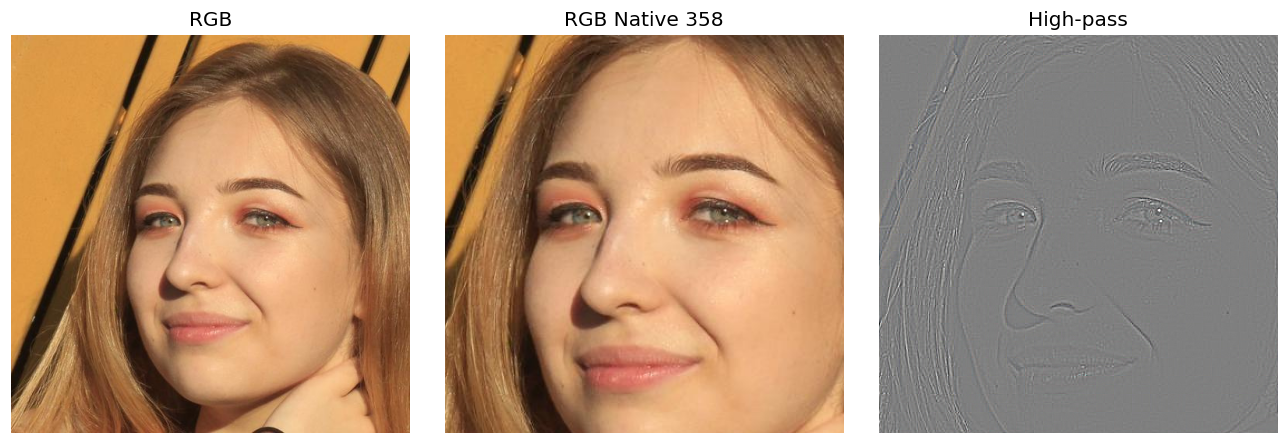

In [ ]:
import torch
from torchvision.transforms import functional as TF
from ailaai.data import decode_rgb
from ailaai.visuals import show_views
VIEW_SPEC = {"crop": rgb_cfg.view["crop"],
             **{k: hp_cfg.view[k] for k in ("kernel", "sigma", "gain", "offset")}}
RGB_VIEW_SPEC = {"crop": rgb_cfg.view["crop"]}
HP_VIEW_SPEC = dict(VIEW_SPEC)
def native_view(x):
    return TF.center_crop(x, [VIEW_SPEC["crop"]] * 2)
def highpass_view(x):
    x = native_view(x)
    low = gaussian_blur_rgb(x, kernel_size=VIEW_SPEC["kernel"], sigma=VIEW_SPEC["sigma"])
    return (VIEW_SPEC["gain"] * (x - low) + VIEW_SPEC["offset"]).clamp(0, 1)
x = decode_rgb(train.iloc[0].path)
for view in (native_view, highpass_view):
    z = view(x)
    assert z.shape == (3, 358, 358) and torch.isfinite(z).all()
    assert 0 <= z.min() and z.max() <= 1
show_views(x, {"RGB Native 358": native_view(x), "High-pass": highpass_view(x)})
rgb_cfg = replace(rgb_cfg, view={"name": "native", "crop": VIEW_SPEC["crop"]})
hp_cfg = replace(hp_cfg, view={"name": "highpass", **VIEW_SPEC})
print("Normalize:", rgb_cfg.normalize_mean, rgb_cfg.normalize_std)

## 5. Tạo mô hình

Hàm `model_factory` tạo ResNet34 và thay tầng phân loại cuối (`fc`) bằng tầng có hai đầu ra cho Real và Fake.

Các tham số được chia thành nhóm để AdamW dùng tốc độ học khác nhau: thấp hơn ở backbone đã có trọng số tiền huấn luyện và cao hơn ở tầng phân loại mới.

In [ ]:
from torch import nn
from torchvision import models
from ailaai.models import attach_optimizer_groups
MODEL_BUILDERS = {
    "resnet34": (models.resnet34, models.ResNet34_Weights),
    "resnet18": (models.resnet18, models.ResNet18_Weights),
}
def model_factory(*, initialize):
    builder, weight_enum = MODEL_BUILDERS[MODEL_SPEC["backbone"]]
    weights = weight_enum[MODEL_SPEC["weights"]] if initialize else None
    model = builder(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 2)
    attach_optimizer_groups(model, head=model.fc)
    return model

### Đọc ảnh thành batch

`FaceDataset` trả về ảnh RGB, nhãn và tên tệp. Ảnh còn ở dải [0, 1]; sau khi ghép thành batch, ta mới crop hoặc lọc High-pass, rồi chuẩn hóa bằng mean/std của ImageNet.

Các hàm dưới được gọi trực tiếp trong phần huấn luyện. Bạn có thể sửa từng bước ngay tại cell để quan sát tác động. Phần III.5 của bài đọc giải thích thứ tự nạp ảnh, biến đổi, chuẩn hóa và đưa vào mạng.

Preset bài học để smoothing = 0 và TTA = False. Khi đối chiếu bảng OOF lịch sử, nhớ rằng bảng đó dùng smoothing = 0,03 và flip TTA.

In [ ]:
# Định nghĩa trực tiếp trong cell: FaceDataset,make_loader
class FaceDataset(Dataset[tuple[torch.Tensor, int, str]]):
    """Decode images without resizing; the engine applies the injected view."""

    def __init__(self, rows: pd.DataFrame, labeled: bool = True) -> None:
        self.rows = rows.reset_index(drop=True).copy()
        self.labeled = labeled

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int, str]:
        row = self.rows.iloc[index]
        label = int(row.label) if self.labeled else -1
        return decode_rgb(row.path), label, str(row.file_name)


def make_loader(
    rows: pd.DataFrame,
    batch_size: int,
    labeled: bool = True,
    shuffle: bool = False,
    seed: int = 2026,
    num_workers: int = 0,
) -> DataLoader:
    """Construct a worker-safe loader for notebook-defined transform functions."""
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(FaceDataset(rows, labeled=labeled), batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(), generator=generator)

### Xử lý ảnh trước khi đưa vào mạng

Ảnh train có thể được lật ngẫu nhiên để tăng dữ liệu. Ảnh validation giữ nguyên thứ tự và không áp dụng phép lật ngẫu nhiên này. Cả hai đều đi qua cùng phép crop/lọc, sau đó mới được chuẩn hóa.

In [ ]:
# Định nghĩa trực tiếp trong cell: _normalize,_view_batch
def _normalize(images: torch.Tensor, cfg: TrainConfig) -> torch.Tensor:
    mean = images.new_tensor(cfg.normalize_mean).view(1, 3, 1, 1)
    std = images.new_tensor(cfg.normalize_std).view(1, 3, 1, 1)
    if images.ndim != 4 or images.shape[1] != 3:
        raise ValueError(f"view_fn must return BCHW RGB, received {tuple(images.shape)}")
    if not torch.isfinite(images).all() or images.min() < 0 or images.max() > 1:
        raise ValueError("view_fn must return finite values in [0, 1] before normalization.")
    return (images - mean) / std


def _view_batch(batch: torch.Tensor, view_fn: ViewFunction, cfg: TrainConfig, augment: bool) -> torch.Tensor:
    if augment:
        probability = float(cfg.augmentation.get("horizontal_flip_probability", 0.0))
        if not 0 <= probability <= 1:
            raise ValueError("horizontal_flip_probability must be in [0, 1].")
        flips = torch.rand(batch.shape[0], device=batch.device) < probability
        batch = torch.where(flips[:, None, None, None], batch.flip(-1), batch)
    viewed = view_fn(batch)
    if not isinstance(viewed, torch.Tensor) or viewed.shape[0] != batch.shape[0]:
        raise ValueError("view_fn must return a tensor with the same batch size.")
    return _normalize(viewed, cfg)

### Những tham số nào được cập nhật?

Backbone đã học từ ImageNet, còn head được khởi tạo cho bài toán hai lớp, nên ta có thể đặt learning rate riêng cho hai phần. Nếu khóa backbone, optimizer chỉ cập nhật head. Các lớp BatchNorm trong backbone cũng phải giữ ở chế độ `eval` để thống kê của chúng không tiếp tục đổi.

In [ ]:
# Định nghĩa trực tiếp trong cell: optimizer_parameter_groups
def optimizer_parameter_groups(model: nn.Module, backbone_lr: float, head_lr: float) -> list[dict[str, Any]]:
    """Return nonempty, disjoint optimizer groups for backbone and classifier."""
    groups = {"backbone": [], "head": []}
    for parameter in model.parameters():
        if parameter.requires_grad:
            group = getattr(parameter, "_ailaai_group", "backbone")
            if group not in groups:
                raise ValueError(f"Unknown optimizer parameter group {group!r}.")
            groups[group].append(parameter)
    if not groups["head"]:
        raise ValueError("Classifier optimizer group must contain trainable parameters.")
    return [{"params": params, "lr": lr} for params, lr in
            [(groups["backbone"], backbone_lr), (groups["head"], head_lr)] if params]

In [ ]:
# Định nghĩa trực tiếp trong cell: _optimizer
def _optimizer(model: nn.Module, cfg: TrainConfig) -> torch.optim.Optimizer:
    groups = optimizer_parameter_groups(model, cfg.backbone_lr, cfg.head_lr)
    return torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)

### Theo dõi một epoch huấn luyện

Mạng trả hai logits cho mỗi ảnh. Cross-Entropy nhận các logits này cùng nhãn kiểu `long`; làm mịn nhãn và trọng số từng ảnh cũng được áp dụng tại bước tính loss.

Sau `backward`, optimizer cập nhật tham số. Khi dùng gradient accumulation, vài batch góp gradient trước một lần cập nhật; nhóm cuối có thể ít batch hơn nên phải chia loss theo đúng số batch của nhóm đó. AMP được bật khi chạy trên CUDA.

In [ ]:
# Định nghĩa trực tiếp trong cell: train_one_epoch
def train_one_epoch(model, epoch_train, optimizer, scaler, cfg, view_fn, device, sample_weights=None):
    """One explicit optimization epoch, also usable for a bounded CPU exercise."""
    model.train()
    if getattr(model, "_freeze_backbone", False):
        model.eval()
        model.fc.train()
    optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0
    correct = 0
    seen = 0
    accumulation = cfg.accumulation
    for step, (images, target, file_names) in enumerate(epoch_train):
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        prepared = _view_batch(images, view_fn, cfg, augment=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(prepared)
            if sample_weights is not None:
                losses = nn.functional.cross_entropy(logits, target, label_smoothing=cfg.label_smoothing, reduction="none")
                weights = losses.new_tensor([sample_weights[name] for name in file_names])
                loss = (losses * weights).mean()
            else:
                loss = nn.functional.cross_entropy(logits, target, label_smoothing=cfg.label_smoothing)
        if not torch.isfinite(loss):
            raise FloatingPointError("Training loss is not finite.")
        loss_value = float(loss.detach())
        group_start = (step // accumulation) * accumulation
        batches_per_group = min(accumulation, len(epoch_train) - group_start)
        scaler.scale(loss / batches_per_group).backward()
        boundary = (step + 1) % accumulation == 0 or step + 1 == len(epoch_train)
        if boundary:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss_value * len(target)
        correct += int((logits.detach().argmax(1) == target).sum())
        seen += len(target)
    return total_loss, correct, seen

### Đánh giá validation và thử flip TTA

`softmax(logits)[:, 1]` cho xác suất Fake. Khi bật TTA, mô hình dự đoán thêm ảnh lật ngang rồi lấy trung bình hai xác suất. Loss validation trong code vẫn được tính trên ảnh gốc.

Toàn bộ bước này chạy với `model.eval()` và không tính gradient. Nhãn validation chỉ dùng để đo loss và Macro-F1.

In [ ]:
# Định nghĩa trực tiếp trong cell: _validation_predictions
def _validation_predictions(
    model: nn.Module,
    loader: DataLoader,
    cfg: TrainConfig,
    view_fn: ViewFunction,
    device: torch.device,
) -> tuple[PredictionTable, float, float]:
    model.eval()
    names: list[str] = []
    labels: list[int] = []
    probabilities: list[float] = []
    losses = 0.0
    with torch.no_grad():
        for images, target, file_names in loader:
            images = images.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            prepared = _view_batch(images, view_fn, cfg, augment=False)
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(prepared)
                loss = nn.functional.cross_entropy(logits, target)
            probability = logits.float().softmax(dim=1)[:, 1]
            if cfg.tta:
                flipped = _view_batch(images.flip(-1), view_fn, cfg, augment=False)
                with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                    flip_probability = model(flipped).float().softmax(1)[:, 1]
                probability = 0.5 * (probability + flip_probability)
            names.extend(file_names)
            labels.extend(target.cpu().tolist())
            probabilities.extend(probability.cpu().tolist())
            losses += float(loss.detach()) * len(target)
    table = PredictionTable(pd.DataFrame({"file_name": names, "label": labels, "prob": probabilities}))
    report = classification_report(labels, probabilities)
    return table, losses / len(labels), float(report["macro_f1"])

### Chạy đủ số epoch và lưu kết quả

`fit_fold` ghép các bước vừa viết thành một lượt huấn luyện. Sau mỗi epoch, hàm lưu đường học và checkpoint; ở epoch cuối, nó xuất dự đoán kèm tên ảnh để dùng cho phần so sánh.

Checkpoint giữ cả trạng thái optimizer, scheduler và bộ sinh số ngẫu nhiên để có thể học tiếp sau khi kernel khởi động lại. Nếu chọn `load_run`, cấu hình sẽ được kiểm tra trước khi nạp kết quả.

In [ ]:
# Định nghĩa trực tiếp trong cell: fit_fold,load_run
def fit_fold(
    workspace: Workspace,
    cfg: TrainConfig,
    branch: str,
    train_rows: pd.DataFrame,
    val_rows: pd.DataFrame,
    model_factory: ModelFactory,
    view_fn: ViewFunction,
    view_spec: Mapping[str, Any],
    model_spec: Mapping[str, Any],
    sample_weights: Mapping[str, float] | None = None,
    *, allow_cpu: bool = False,
) -> RunInfo:
    """Fit one branch on the provided training rows and validate each epoch."""
    if not torch.cuda.is_available() and not allow_cpu:
        raise RuntimeError("fit_fold needs a CUDA GPU. Use load_run for a released checkpoint.")
    if branch not in {"rgb", "highpass", "resampled", "wavelet", "edge_weighted"}:
        raise ValueError("Unknown training branch.")
    if train_rows.empty or val_rows.empty or set(train_rows.file_name) & set(val_rows.file_name):
        raise ValueError("Training and validation rows must be nonempty and disjoint.")
    resolved = _resolved_config(workspace, cfg, branch, train_rows, val_rows, model_factory, view_fn, view_spec, model_spec, sample_weights)
    sample_weights = resolved["recipe"].get("sample_weights")
    run_dir = _run_directory(workspace, branch, resolved)
    run_dir.mkdir(parents=True, exist_ok=True)
    print(f"Lượt chạy {branch}: {run_dir}", flush=True)
    config_path = run_dir / "config.json"
    checkpoint_path = run_dir / "last.pt"
    if checkpoint_path.exists() and not config_path.exists():
        raise ValueError(f"Checkpoint has no saved recipe; move it aside or use a new run_id: {run_dir}")
    if config_path.exists() and json.loads(config_path.read_text()) != resolved:
        raise ValueError(f"Run configuration changed; choose a new run_id. Existing run: {run_dir}")
    status_path = run_dir / "run_status.json"
    status = json.loads(status_path.read_text()) if status_path.is_file() else {}
    if status.get("status") == "complete" and checkpoint_path.is_file():
        print("Đã có lượt chạy hoàn tất; đang nạp kết quả.", flush=True)
        return load_run(workspace, cfg, branch, train_rows, val_rows, model_factory,
                        view_fn, view_spec, model_spec, checkpoint_source=checkpoint_path, sample_weights=sample_weights)
    write_json(config_path, resolved)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _seed(cfg.seed)
    model = model_factory(initialize=not checkpoint_path.is_file()).to(device)
    optimizer = _optimizer(model, cfg)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")
    validation_loader = make_loader(val_rows, cfg.batch_size, labeled=True, shuffle=False, seed=cfg.seed)
    curves_path = run_dir / "curves.csv"
    start_epoch = 0
    records = pd.read_csv(curves_path).to_dict("records") if curves_path.is_file() else []
    if checkpoint_path.is_file():
        state = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(state["model"], strict=True)
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        torch.set_rng_state(state["torch_rng"].cpu())
        if state.get("cuda_rng"):
            torch.cuda.set_rng_state_all([value.cpu() for value in state["cuda_rng"]])
        np.random.set_state(state["numpy_rng"])
        random.setstate(state["python_rng"])
        start_epoch = int(state["epoch"])
        records = [record for record in records if int(record["epoch"]) <= start_epoch]
    write_json(run_dir / "run_status.json", {"status": "running", "start_epoch": start_epoch, "config_sha256": sha256_file(config_path)})
    for epoch in range(start_epoch, cfg.epochs):
        tick = time.monotonic()
        epoch_train = make_loader(train_rows, cfg.batch_size, labeled=True, shuffle=True, seed=cfg.seed + epoch)
        total_loss, correct, seen = train_one_epoch(
            model, epoch_train, optimizer, scaler, cfg, view_fn, device, sample_weights)
        scheduler.step()
        predictions, val_loss, val_f1 = _validation_predictions(model, validation_loader, cfg, view_fn, device)
        records.append({"epoch": epoch + 1, "train_loss": total_loss / seen, "train_accuracy": correct / seen,
                        "val_loss": val_loss, "val_macro_f1": val_f1, "seconds": time.monotonic() - tick,
                        "backbone_lr": optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 1 else 0.0,
                        "head_lr": optimizer.param_groups[-1]["lr"]})
        _save_curves(curves_path, records)
        pending_checkpoint = checkpoint_path.with_suffix(".pt.partial")
        torch.save(_checkpoint_state(model, optimizer, scheduler, scaler, epoch + 1), pending_checkpoint)
        pending_checkpoint.replace(checkpoint_path)
        print(f"{branch} | epoch {epoch + 1}/{cfg.epochs} | loss {total_loss / seen:.4f} | "
              f"val F1 {val_f1:.4f} | {records[-1]['seconds']:.1f}s", flush=True)
    if len(records) < cfg.epochs:
        raise RuntimeError("Training ended before the configured terminal epoch.")
    prediction_meta = {
        "source": "learner_run", "run_id": workspace.run_id, "branch": branch,
        "checkpoint_sha256": sha256_file(checkpoint_path), "config_sha256": sha256_file(config_path),
        "split_sha256": resolved["split_sha256"], "validation_ids_sha256": resolved["validation_ids_sha256"],
        "validation_manifest": "validation_manifest.csv",
        "model_spec": dict(model_spec), "view_spec": dict(view_spec), "label_map": {"0": "Real", "1": "Fake"},
    }
    predictions, _, _ = _validation_predictions(model, validation_loader, cfg, view_fn, device)
    predictions = PredictionTable(predictions.rows, prediction_meta)
    predictions.save(run_dir / "val_predictions.csv")
    pd.DataFrame(val_rows).to_csv(run_dir / "validation_manifest.csv", index=False)
    write_json(run_dir / "run_status.json", {"status": "complete", "epochs": cfg.epochs,
                                             "checkpoint_sha256": prediction_meta["checkpoint_sha256"]})
    write_json(workspace.artifact_root / f"{branch}_active.json", {"directory": run_dir.name})
    result = RunInfo(workspace.run_id, branch, run_dir, checkpoint_path, pd.DataFrame(records), predictions, prediction_meta)
    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()
    return result


def load_run(
    workspace: Workspace,
    cfg: TrainConfig,
    branch: str,
    train_rows: pd.DataFrame,
    val_rows: pd.DataFrame,
    model_factory: ModelFactory,
    view_fn: ViewFunction,
    view_spec: Mapping[str, Any],
    model_spec: Mapping[str, Any],
    checkpoint_source: str | Path | None = None,
    sample_weights: Mapping[str, float] | None = None,
) -> RunInfo:
    """Load a completed branch after exact config and callable checks."""
    run, model, device = _load_checkpoint(workspace, cfg, branch, train_rows, val_rows,
                                          model_factory, view_fn, view_spec, model_spec, checkpoint_source, sample_weights)
    if not run.val_predictions.rows.file_name.isin(val_rows.file_name).all() or len(run.val_predictions.rows) != len(val_rows):
        raise ValueError("Stored validation predictions do not cover the current fold.")
    write_json(workspace.artifact_root / f"{branch}_active.json", {"directory": run.run_dir.name})
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return run

## 6. Huấn luyện hoặc nạp nhánh RGB

Nếu chọn `"train"`, cell dưới huấn luyện nhánh RGB. AMP (Automatic Mixed Precision) kết hợp các mức độ chính xác số học khi chạy trên GPU để giảm nhu cầu bộ nhớ và hỗ trợ tốc độ tính toán. Nếu chọn `"load"`, cell nạp lượt chạy đã lưu.

Theo dõi loss Cross-Entropy và Macro-F1 trên validation sau mỗi epoch.

Lượt chạy rgb: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/student_e2e_reading_v2/rgb
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 218MB/s]


rgb | epoch 1/15 | loss 0.4476 | val F1 0.8794 | 28.3s
rgb | epoch 2/15 | loss 0.2220 | val F1 0.8721 | 26.6s
rgb | epoch 3/15 | loss 0.1276 | val F1 0.9023 | 25.1s
rgb | epoch 4/15 | loss 0.1316 | val F1 0.9000 | 25.2s
rgb | epoch 5/15 | loss 0.0801 | val F1 0.9198 | 25.2s
rgb | epoch 6/15 | loss 0.0508 | val F1 0.9250 | 25.5s
rgb | epoch 7/15 | loss 0.0470 | val F1 0.9224 | 26.5s
rgb | epoch 8/15 | loss 0.0325 | val F1 0.9248 | 28.8s
rgb | epoch 9/15 | loss 0.0232 | val F1 0.9299 | 25.7s
rgb | epoch 10/15 | loss 0.0073 | val F1 0.9275 | 25.4s
rgb | epoch 11/15 | loss 0.0078 | val F1 0.9300 | 25.5s
rgb | epoch 12/15 | loss 0.0108 | val F1 0.9200 | 25.6s
rgb | epoch 13/15 | loss 0.0041 | val F1 0.9300 | 25.5s
rgb | epoch 14/15 | loss 0.0046 | val F1 0.9375 | 30.4s
rgb | epoch 15/15 | loss 0.0037 | val F1 0.9350 | 26.8s
{'run_id': 'student_e2e_reading_v2', 'branch': 'rgb', 'epochs': 15, 'checkpoint': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/student_e2e_reading

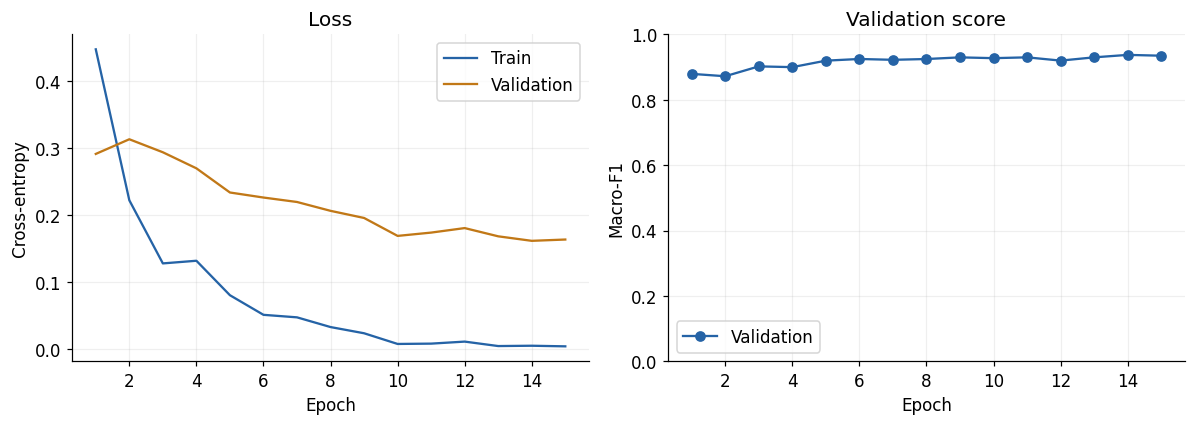

In [ ]:
from ailaai.visuals import show_learning_curves
rgb_kwargs = dict(branch="rgb", train_rows=fit_rows, val_rows=val_rows,
                  model_factory=model_factory, view_fn=native_view,
                  view_spec=RGB_VIEW_SPEC, model_spec=MODEL_SPEC)
if MODE["rgb"] == "train":
    rgb_run = fit_fold(ws, rgb_cfg, **rgb_kwargs)
else:
    rgb_run = load_run(ws, rgb_cfg, **rgb_kwargs,
                      checkpoint_source=e2e_cfg["checkpoint_sources"]["rgb"])
show_learning_curves(rgb_run.curves)
print(rgb_run.summary())

## 7. Huấn luyện hoặc nạp nhánh High-pass

Nhánh High-pass dùng cùng fold với RGB, nhưng đầu vào là phần chênh lệch giữa ảnh gốc và ảnh làm mờ Gaussian. Cell dưới huấn luyện hoặc nạp mô hình theo chế độ đã chọn.

Quan sát đường cong học của hai nhánh để xem loss và điểm validation thay đổi ra sao.

Lượt chạy highpass: /content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/artifacts/student_e2e_reading_v2/highpass
highpass | epoch 1/15 | loss 0.4831 | val F1 0.7828 | 26.5s
highpass | epoch 2/15 | loss 0.2645 | val F1 0.8797 | 26.6s
highpass | epoch 3/15 | loss 0.1452 | val F1 0.8720 | 27.4s
highpass | epoch 4/15 | loss 0.1418 | val F1 0.8607 | 27.6s
highpass | epoch 5/15 | loss 0.0735 | val F1 0.9124 | 26.8s
highpass | epoch 6/15 | loss 0.0732 | val F1 0.9124 | 26.9s
highpass | epoch 7/15 | loss 0.0525 | val F1 0.9350 | 26.8s
highpass | epoch 8/15 | loss 0.0314 | val F1 0.9300 | 27.1s
highpass | epoch 9/15 | loss 0.0277 | val F1 0.9147 | 27.0s
highpass | epoch 10/15 | loss 0.0066 | val F1 0.9400 | 26.9s
highpass | epoch 11/15 | loss 0.0062 | val F1 0.9475 | 26.9s
highpass | epoch 12/15 | loss 0.0108 | val F1 0.9400 | 27.0s
highpass | epoch 13/15 | loss 0.0058 | val F1 0.9300 | 27.5s
highpass | epoch 14/15 | loss 0.0060 | val F1 0.9400 | 27.1s
highpass | epoch 15/15 | loss 0.0049

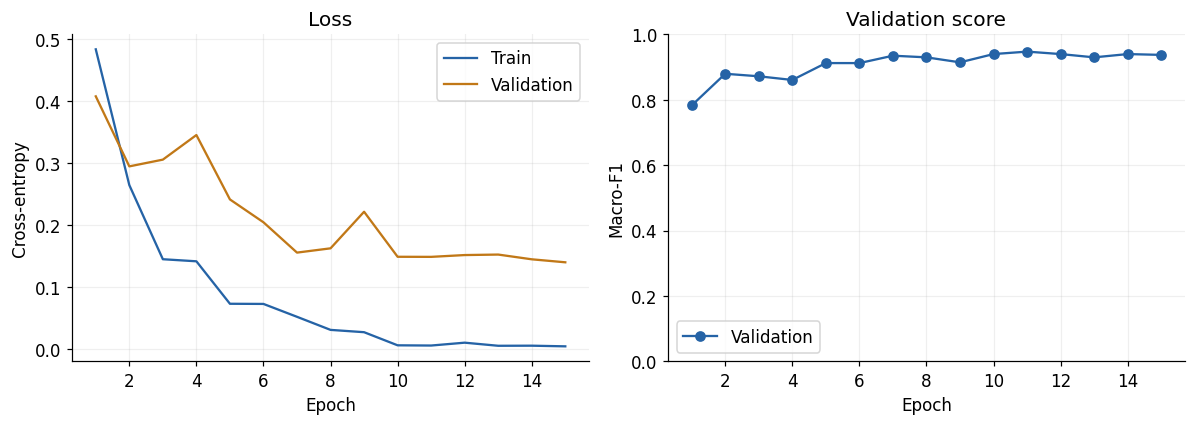

In [ ]:
hp_kwargs = dict(branch="highpass", train_rows=fit_rows, val_rows=val_rows,
                 model_factory=model_factory, view_fn=highpass_view,
                 view_spec=HP_VIEW_SPEC, model_spec=MODEL_SPEC)
if MODE["highpass"] == "train":
    hp_run = fit_fold(ws, hp_cfg, **hp_kwargs)
else:
    hp_run = load_run(ws, hp_cfg, **hp_kwargs,
                     checkpoint_source=e2e_cfg["checkpoint_sources"]["highpass"])
show_learning_curves(hp_run.curves)
print(hp_run.summary())

## 8. Lấy trung bình xác suất hai nhánh

Với mỗi ảnh validation, ta tính:

$$p_{\text{Mean}} = 0.5 \cdot p_{\text{RGB}} + 0.5 \cdot p_{\text{HP}}$$

Dùng ngưỡng $t = 0.50$ để chuyển xác suất thành nhãn. So sánh Macro-F1 của từng nhánh với kết quả lấy trung bình để xem việc kết hợp có cải thiện trong lượt chạy này không.

In [ ]:
import pandas as pd
from sklearn.metrics import f1_score
from ailaai.predictions import align_predictions
val = align_predictions(rgb_run.val_predictions, hp_run.val_predictions,
                        expected_rows=val_rows)
val["p_mean"] = 0.5 * val.p_rgb + 0.5 * val.p_hp
scores = pd.DataFrame([
    {"model": name, "macro_f1": f1_score(val.label, val[col] >= 0.5,
        labels=[0, 1], average="macro", zero_division=0)}
    for name, col in [("RGB", "p_rgb"), ("High-pass", "p_hp"), ("Mean 50/50", "p_mean")]
])
display(scores)

,model,macro_f1
0,RGB,0.934993
1,High-pass,0.937496
2,Mean 50/50,0.939994


### Mở rộng: tạo OOF thật từ cả năm fold

`RUN_OOF=False` giữ pipeline chính ở fold đang chọn. Bật cờ này cần **10 lượt huấn luyện** (5 RGB + 5 High-pass). Mỗi ảnh chỉ được dự đoán bởi mô hình giữ ảnh đó ngoài train. Trong mỗi fold, flip TTA gộp hai cách nhìn của **cùng mô hình**; không gộp dự đoán của mô hình đã học ảnh đó.

`OOF_LABEL_SMOOTHING` và `OOF_TTA` đặt mức làm mịn nhãn và bật/tắt flip TTA cho lượt OOF. Khi so với bảng trong bài đọc, đối chiếu thêm backbone, kích thước ảnh và số epoch trong cấu hình. Phần này dùng dữ liệu train có nhãn; Private Test dành cho bước tạo submission.

In [ ]:
RUN_OOF = False
OOF_LABEL_SMOOTHING = 0.03
OOF_TTA = True
if RUN_OOF:
    oof_parts = {"rgb": [], "highpass": []}
    for fold in range(5):
        fold_train, fold_val = load_fold_split(train, TASK / "assets/splits/train_folds.csv", fold=fold)
        fold_ws = Workspace.from_root(TASK, run_id=f"{RUN_ID}_oof_fold{fold}")
        for branch, base_cfg, view, view_spec in [("rgb", rgb_cfg, native_view, RGB_VIEW_SPEC),
                                                  ("highpass", hp_cfg, highpass_view, HP_VIEW_SPEC)]:
            fold_cfg = replace(base_cfg, label_smoothing=OOF_LABEL_SMOOTHING, tta=OOF_TTA)
            fold_run = fit_fold(fold_ws, fold_cfg, branch, fold_train, fold_val,
                                model_factory, view, view_spec, MODEL_SPEC)
            oof_parts[branch].append(fold_run.val_predictions.rows.assign(fold=fold))
    oof_tables = {}
    for branch, parts in oof_parts.items():
        frame = pd.concat(parts, ignore_index=True)
        assert frame.file_name.is_unique and set(frame.file_name) == set(train.file_name)
        assert frame.groupby("fold").size().eq(len(train)//5).all()
        frame.to_csv(ws.output_root / f"{branch}_oof.csv", index=False)
        oof_tables[branch] = frame
    oof = align_predictions(oof_tables["rgb"], oof_tables["highpass"], expected_rows=train)
    oof["p_mean"] = .5 * (oof.p_rgb + oof.p_hp)
    display(pd.DataFrame([{ "Nhánh": col, **classification_report(oof.label, oof[col])}
                          for col in ["p_rgb", "p_hp", "p_mean"]]))
    oof.to_csv(ws.output_root / "paired_oof.csv", index=False)
else:
    print("Pipeline chính dùng một fold; RUN_OOF=True mới tạo đủ 2.000 dự đoán OOF.")

Pipeline chính dùng một fold; RUN_OOF=True mới tạo đủ 2.000 dự đoán OOF.


## 9. Chốt cấu hình và lưu thông tin lượt chạy

Trước khi dự đoán Private Test, ta lưu trọng số kết hợp, ngưỡng $t = 0.50$, đường dẫn checkpoint và điểm validation vào `decision.json`. Tệp này ghi lại các lựa chọn đã dùng để tiện xem lại hoặc chạy lại.

In [ ]:
from ailaai.pipeline import save_decision
decision = save_decision(
    ws, runs={"rgb": rgb_run, "highpass": hp_run},
    method="probability_mean", weights={"rgb": 0.5, "highpass": 0.5},
    threshold=0.5, label_map={0: "Real", 1: "Fake"},
    test_rows=test, validation_scores=scores)
print(decision.summary())

{'decision_id': '0bcc09f8381a7aad', 'path': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/decision.json', 'threshold': 0.5, 'weights': {'rgb': 0.5, 'highpass': 0.5}}


### Từ checkpoint đến xác suất của từng ảnh

Cờ TTA được dùng giống bước validation. Mỗi xác suất đi kèm tên ảnh; ta ghép theo tên trước khi lấy trung bình hai nhánh.

In [ ]:
# Định nghĩa trực tiếp trong cell: predict
def predict(
    run: RunInfo,
    rows: pd.DataFrame,
    model_factory: ModelFactory,
    view_fn: ViewFunction,
    view_spec: Mapping[str, Any],
    model_spec: Mapping[str, Any],
    decision: Any = None,
) -> PredictionTable:
    """Predict P(Fake) for each row using a completed checkpoint and injected view."""
    if rows.empty or not {"file_name", "path"}.issubset(rows.columns) or not rows.file_name.is_unique:
        raise ValueError("Prediction rows need unique file_name and path columns.")
    saved = json.loads((run.run_dir / "config.json").read_text())
    if saved["model_factory_sha256"] != _callable_digest(model_factory, model_spec):
        raise ValueError("model_factory differs from the trained checkpoint recipe.")
    if saved["view_fn_sha256"] != _callable_digest(view_fn, view_spec):
        raise ValueError("view_fn or its declared parameters differ from the trained recipe.")
    if decision is not None:
        branch = decision.weights.get(run.branch)
        recorded = decision.path
        payload = json.loads(recorded.read_text()) if recorded.is_file() else {}
        receipt = payload.get("branches", {}).get(run.branch, {})
        if branch is None or receipt.get("checkpoint_sha256") != sha256_file(run.checkpoint_path):
            raise ValueError("The decision does not select this branch checkpoint.")
    cfg = TrainConfig(**{**saved["train_config"], "normalize_mean": tuple(saved["train_config"]["normalize_mean"]),
                         "normalize_std": tuple(saved["train_config"]["normalize_std"])})
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model_factory(initialize=False).to(device)
    state = torch.load(run.checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(state["model"], strict=True)
    loader = make_loader(rows, cfg.batch_size, labeled=False, shuffle=False, seed=cfg.seed)
    model.eval()
    names: list[str] = []
    probs: list[float] = []
    with torch.no_grad():
        for images, _, file_names in loader:
            images = images.to(device, non_blocking=True)
            prepared = _view_batch(images, view_fn, cfg, augment=False)
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(prepared).float()
                probability = logits.softmax(1)[:, 1]
                if cfg.tta:
                    flipped = _view_batch(images.flip(-1), view_fn, cfg, augment=False)
                    probability = 0.5 * (probability + model(flipped).float().softmax(1)[:, 1])
            names.extend(file_names)
            probs.extend(probability.cpu().tolist())
    metadata = {"source": "learner_run", "run_id": run.run_id, "branch": run.branch,
                "checkpoint_sha256": sha256_file(run.checkpoint_path), "model_spec": dict(model_spec),
                "view_spec": dict(view_spec), "decision_id": getattr(decision, "decision_id", None),
                "label_map": {"0": "Real", "1": "Fake"}}
    table = PredictionTable(pd.DataFrame({"file_name": names, "prob": probs}), metadata)
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return table

## 10. Dự đoán trên Private Test

Hai mô hình lần lượt dự đoán trên 200 ảnh test. Xác suất của từng nhánh được lưu vào CSV, rồi lấy trung bình 50/50 để tạo nhãn cuối cùng: `0` cho Real và `1` cho Fake.

In [ ]:
rgb_test = predict(rgb_run, test, model_factory=model_factory,
                   view_fn=native_view, view_spec=RGB_VIEW_SPEC,
                   model_spec=MODEL_SPEC, decision=decision)
rgb_test.save(ws.output_root / "rgb_test.csv")

(PosixPath('/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/rgb_test.csv'),
 PosixPath('/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/rgb_test.csv.meta.json'))

In [ ]:
hp_test = predict(hp_run, test, model_factory=model_factory,
                  view_fn=highpass_view, view_spec=HP_VIEW_SPEC,
                  model_spec=MODEL_SPEC, decision=decision)
hp_test.save(ws.output_root / "highpass_test.csv")

(PosixPath('/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/highpass_test.csv'),
 PosixPath('/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/highpass_test.csv.meta.json'))

In [ ]:
assert decision.weights == {"rgb": 0.5, "highpass": 0.5}
pred = align_predictions(rgb_test, hp_test, expected_rows=test)
pred["p_mean"] = 0.5 * pred.p_rgb + 0.5 * pred.p_hp
submission = pd.DataFrame({
    "file_name": pred.file_name,
    "category_id": (pred.p_mean >= decision.threshold).astype("int64")})
pred.to_csv(ws.output_root / "mean_test.csv", index=False)
display(submission.head())
print("Số dòng:", len(submission))

,file_name,category_id
0,00001.jpg,1
1,00002.jpg,1
2,00003.jpg,0
3,00004.jpg,0
4,00005.jpg,1


Số dòng: 200


### Đóng gói CSV và đọc lại để kiểm tra

Theo Reading III.8, ZIP chỉ chứa `submission.csv` ở thư mục gốc. CSV phải có đúng thứ tự hai cột, đủ tên ảnh test, nhãn 0 hoặc 1, không trùng và không thiếu giá trị. Các hàm dưới thực hiện việc ghi file và kiểm tra lại nội dung vừa ghi.

In [ ]:
# Định nghĩa trực tiếp trong cell: SubmissionReceipt,_validate_frame
@dataclass(frozen=True, slots=True)
class SubmissionReceipt:
    """Validation details for a written submission archive."""

    path: Path
    sha256: str
    row_count: int
    member: str
    columns: tuple[str, ...]

    def summary(self) -> dict[str, Any]:
        return {"path": str(self.path), "sha256": self.sha256, "row_count": self.row_count,
                "member": self.member, "columns": list(self.columns), "valid": True}


def _validate_frame(frame: pd.DataFrame, expected_names: Iterable[str], expected_count: int) -> pd.DataFrame:
    names = list(expected_names)
    if len(names) != expected_count or len(set(names)) != expected_count:
        raise ValueError(f"Expected test names must contain exactly {expected_count} unique entries.")
    if list(frame.columns) != ["file_name", "category_id"]:
        raise ValueError("Submission columns and order must be exactly file_name,category_id.")
    if len(frame) != expected_count:
        raise ValueError(f"Submission must have exactly {expected_count} data rows; found {len(frame)}.")
    result = frame.copy()
    if result.isna().any().any():
        raise ValueError("Submission contains missing values.")
    result["file_name"] = result.file_name.astype(str)
    if not result.file_name.is_unique:
        raise ValueError("Submission contains duplicate file_name values.")
    if set(result.file_name) != set(names):
        missing = sorted(set(names) - set(result.file_name))[:5]
        extra = sorted(set(result.file_name) - set(names))[:5]
        raise ValueError(f"Submission file names differ from test; missing={missing}, extra={extra}.")
    if not result.category_id.astype(str).isin(["0", "1"]).all():
        raise ValueError("category_id must contain literal integer labels 0 or 1.")
    labels = pd.to_numeric(result.category_id, errors="coerce")
    if labels.isna().any() or not np.equal(labels, np.floor(labels)).all() or not labels.isin([0, 1]).all():
        raise ValueError("category_id values must be integer labels 0 or 1.")
    result["category_id"] = labels.astype("int64")
    return result

In [ ]:
# Định nghĩa trực tiếp trong cell: validate_submission,export_submission
def validate_submission(
    zip_path: str | Path,
    expected_names: Iterable[str],
    expected_count: int = 200,
    expected_frame: pd.DataFrame | None = None,
    receipt_path: str | Path | None = None,
) -> SubmissionReceipt:
    """Read a ZIP back and check member, CRC, schema, IDs, labels, and optional values."""
    source = Path(zip_path)
    if not source.is_file():
        raise FileNotFoundError(source)
    try:
        with zipfile.ZipFile(source) as archive:
            if archive.testzip() is not None:
                raise ValueError("Submission ZIP CRC check failed.")
            members = archive.namelist()
            if members != ["submission.csv"]:
                raise ValueError("ZIP must contain exactly one root member named submission.csv.")
            with archive.open("submission.csv") as handle:
                returned = pd.read_csv(handle, dtype={"file_name": str, "category_id": str})
    except zipfile.BadZipFile as exc:
        raise ValueError("Submission is not a readable ZIP archive.") from exc
    returned = _validate_frame(returned, expected_names, expected_count)
    if expected_frame is not None:
        expected = _validate_frame(expected_frame, expected_names, expected_count)
        left = returned.sort_values("file_name").reset_index(drop=True)
        right = expected.sort_values("file_name").reset_index(drop=True)
        if not left.equals(right):
            raise ValueError("Read-back submission values do not match the frame that was exported.")
    receipt = SubmissionReceipt(source.resolve(), sha256_file(source), len(returned), "submission.csv", tuple(returned.columns))
    if receipt_path:
        write_json(receipt_path, receipt.summary())
    return receipt


def export_submission(
    frame: pd.DataFrame,
    zip_path: str | Path,
    expected_names: Iterable[str],
    expected_count: int = 200,
) -> Path:
    """Validate and atomically create a ZIP with one root-level submission.csv."""
    expected_list = list(expected_names)
    normalized = _validate_frame(frame, expected_list, expected_count)
    destination = Path(zip_path)
    destination.parent.mkdir(parents=True, exist_ok=True)
    fd, temp_name = tempfile.mkstemp(prefix=f".{destination.name}.", suffix=".partial", dir=destination.parent)
    os.close(fd)
    temporary = Path(temp_name)
    try:
        with zipfile.ZipFile(temporary, "w", compression=zipfile.ZIP_DEFLATED) as archive:
            archive.writestr("submission.csv", normalized.to_csv(index=False, lineterminator="\n"))
        validate_submission(temporary, expected_list, expected_count, expected_frame=normalized)
        temporary.replace(destination)
    except Exception:
        temporary.unlink(missing_ok=True)
        raise
    return destination

## 11. Tạo và kiểm tra `submission.zip`

Hàm `export_submission` tạo tệp nộp bài. Hàm `validate_submission` kiểm tra:
- CSV nằm ở gốc tệp ZIP.
- Có đúng 200 dòng, tương ứng với danh sách ảnh test.
- Có hai cột `file_name,category_id`.
- Không thiếu giá trị hoặc trùng tên ảnh; nhãn là số nguyên 0 hoặc 1.

Nếu chạy trên Google Colab, bước cuối gửi tệp `submission.zip` về máy của bạn.

In [ ]:
zip_path = export_submission(
    submission, ws.output_root / "submission.zip",
    expected_names=test.file_name.tolist(), expected_count=200)
print(zip_path)

/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/submission.zip


In [ ]:
receipt = validate_submission(
    zip_path, expected_names=test.file_name.tolist(), expected_count=200,
    expected_frame=submission, receipt_path=ws.output_root / "submission_check.json")
print(receipt.summary())
if "google.colab" in sys.modules:
    from google.colab import files
    files.download(str(zip_path))

{'path': '/content/Olympic_AI_PTIT_2026_preliminary_round/AI_LA_AI/outputs/student_e2e_reading_v2/submission.zip', 'sha256': '980663bcc1f7708f67009a0fb05deb5652e42e27a9a4361c3f63e147b8ba321e', 'row_count': 200, 'member': 'submission.csv', 'columns': ['file_name', 'category_id'], 'valid': True}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>